# Exercise 4.A Introduction to Linear Regression

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# NumPy helps with numbers, pandas helps with tables/DataFrames, Matplotlib helps create charts, 
# and scikit-learn gives me the tools for building and testing a linear regression model.

## Lab 1
### Running a sample script

Open the file linear_regression_example.py from your course material folder. Read through the script, then copy its contents into a code cell and run it.

In [5]:
# Sample dataset: hours studied vs. exam score
data = {
    'hours_studied': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'exam_score':    [52, 55, 60, 65, 68, 72, 75, 80, 85, 90]
}
df = pd.DataFrame(data)

# Step 1: Define features (X) and target (y)
X = df[['hours_studied']]   # 2D: double brackets give a DataFrame, not a Series
y = df['exam_score']        # 1D: single brackets give a Series

# Step 2: Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Step 3: Create the model and fit it to training data
model = LinearRegression()
model.fit(X_train, y_train)

print('Model trained successfully.')

Model trained successfully.


### Working through the sample script

In a code cell, print the slope (model.coef_[0]) and intercept (model.intercept_) of the fitted model.

In [6]:
print(f'\nSlope (coefficient): {model.coef_[0]:.2f}')
print(f'Intercept: {model.intercept_:.2f}')

# Here, I’m asking Python to show me the two main parts of the regression equation. The slope tells me how much the predicted exam score 
# changes when hours studied increases by 1. The intercept tells me the predicted score when hours studied is 0.


Slope (coefficient): 4.10
Intercept: 47.68


In another code cell, add the following prediction code:

In [9]:
y_pred = model.predict(X_test)

print('Actual scores: ', list(y_test))
print('Predicted scores:', list(y_pred.round(1)))

# Using the trained model to make predictions on the test data. X_test holds the hours studied that the model has not been tested on yet, 
# and y_pred stores the model’s predicted exam scores. Then I print the actual scores and predicted scores so I can compare how close the model was.

Actual scores:  [85, 55]
Predicted scores: [np.float64(84.6), np.float64(55.9)]


In another code cell, add the following evaluation code to find how much of the variation in your target variable is explained by your model:

In [10]:
r_squared = model.score(X_test, y_test)
print(f'R² score: {r_squared:.3f}')

R² score: 0.998


The R² score tells us how much of the change in exam scores can be explained by hours studied. A score closer to 1 means the model fits the data well, while a score closer to 0 means the model does not explain the data very well.

In another code cell, add the following code to visualize the regression line:

C:\Users\marenzasantarin\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


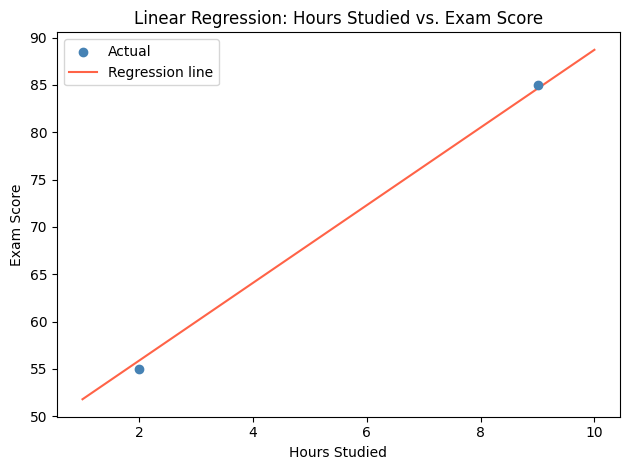

In [26]:
# Scatter plot: actual test data points
plt.scatter(
    X_test, 
    y_test, 
    color='steelblue', 
    label='Actual', 
    zorder=3
)

# Line: model predictions across the full range of X
x_range = np.linspace(
    X['hours_studied'].min(),
    X['hours_studied'].max(),
    100
).reshape(-1, 1)

y_line = model.predict(x_range)
plt.plot(
    x_range, 
    y_line, 
    color='tomato', 
    label='Regression line'
)

plt.xlabel('Hours Studied')
plt.ylabel('Exam Score')
plt.title('Linear Regression: Hours Studied vs. Exam Score')
plt.legend()
plt.tight_layout()
plt.show()

The data points appear to follow the regression line closely, which means hours studied seems to have a strong relationship with exam score. The closer the points are to the line, the better the model is fitting the data.

## Lab 2
### Building your own model

In a code cell, create a DataFrame named df_ads.

In [12]:
ad_data = {
    'monthly_ad_spend': [500, 1000, 1500, 2000, 2500, 3000, 3500, 4000, 4500,
                         5000, 5500, 6000, 6500, 7000, 7500, 8000, 8500, 9000, 9500, 10000],
    'monthly_revenue': [4200, 5100, 6800, 7400, 8900, 9200, 10500, 11800,
                        12400, 13100, 14200, 15600, 15900, 17200, 18100,
                        19400, 20200, 21500, 22100, 23800]
}

df_ads = pd.DataFrame(ad_data)

df_ads

# Creating a small dataset about ad spending and monthly revenue. The data is saved inside a dictionary first, then converted into a 
# pandas DataFrame called df_ads so I can work with it like a table.

,monthly_ad_spend,monthly_revenue
0,500,4200
1,1000,5100
2,1500,6800
3,2000,7400
4,2500,8900
5,3000,9200
6,3500,10500
7,4000,11800
8,4500,12400
9,5000,13100


Define your feature matrix X2 using the monthly_ad_spend column (use double brackets to keep it as a DataFrame), and your target vector y2 using the monthly_revenue column. Print the shape of X2 and the shape of y2.

In [13]:
X2 = df_ads[['monthly_ad_spend']]
y2 = df_ads['monthly_revenue']

print(X2.shape)
print(y2.shape)

# Splitting the data into the feature and the target. X2 is the column the model will use to make predictions, 
# which is monthly ad spend. y2 is what I want the model to predict, which is monthly revenue. I use double brackets for X2 
# because scikit-learn expects the feature to stay as a DataFrame.

(20, 1)
(20,)


Split X2 and y2 into training and test sets using train_test_split. Use test_size=0.2 and random_state=42 to match the approach from Lab 1.

In [14]:
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42
)

# splitting the data into training data and testing data. The model will learn from the training set, 
# then I’ll test it on the testing set to see how well it predicts new data. 
# test_size=0.2 means 20% of the data is saved for testing.

In a separate cell, create a LinearRegression model named model2, fit it to the training data, and print “Model trained successfully.”

In [15]:
model2 = LinearRegression()

model2.fit(X2_train, y2_train)

print("Model trained successfully.")

# Creating a new linear regression model called model2. Then I use .fit() to train the model using ad spend and revenue 
# from the training data. Once it runs successfully, the model has learned the relationship between ad spend and revenue.


Model trained successfully.


Print the slope (model2.coef_[0]) and intercept (model2.intercept_) of the fitted model.

In [16]:
print(f'Slope (coefficient): {model2.coef_[0]:.2f}')
print(f'Intercept: {model2.intercept_:.2f}')

Slope (coefficient): 1.96
Intercept: 3625.89


The slope tells us how much monthly revenue is predicted to increase for each additional dollar spent on ads. For each additional $1 in ad spend, the predicted monthly revenue increases by the slope amount.

### Making predictions and evaluating the model

Use the fitted model to predict revenue for the test set. Print the actual values and the predicted values side by side (rounded to 2 decimal places).

In [17]:
y2_pred = model2.predict(X2_test)

print('Actual revenue: ', list(y2_test))
print('Predicted revenue:', list(y2_pred.round(2)))

# Using the trained model to predict revenue for the test data. Then I compare the actual revenue values with the 
# predicted revenue values to see how close the model’s guesses were.

Actual revenue:  [4200, 21500, 19400, 5100]
Predicted revenue: [np.float64(4603.85), np.float64(21229.03), np.float64(19273.13), np.float64(5581.8)]


Calculate and print the R² score for the test set.

In [18]:
r2_score = model2.score(X2_test, y2_test)

print(f'R² score: {r2_score:.3f}')

R² score: 0.998


The R² score shows how much of the variation in monthly revenue is explained by monthly ad spend. If the score is close to 1, the model appears to be a good fit because ad spend explains most of the changes in revenue.

### Visualizing the results

Create a scatter plot of the full dataset (all X2 values vs. all y2 values). Label the x-axis 'Monthly Ad Spend (dollar sign)', the y-axis 'Monthly Revenue (dollar sign)', and give the plot the title 'Ad Spend vs. Revenue'. Don’t include a regression line yet! Run just the scatter plot
(dots only).

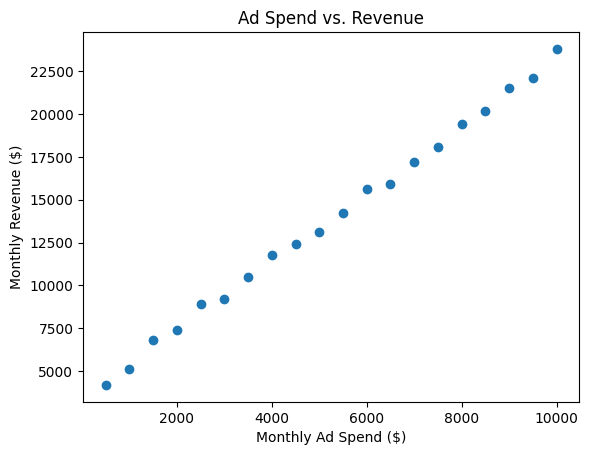

In [21]:
plt.scatter(X2, y2)

plt.xlabel('Monthly Ad Spend ($)')
plt.ylabel('Monthly Revenue ($)')
plt.title('Ad Spend vs. Revenue')

plt.show()

# creating a scatter plot to see the relationship between ad spend and revenue. Each dot represents one month. 
# This helps me visually check whether revenue tends to increase as ad spend increases.

In another cell, copy and paste the code you used to generate a scatter plot. This time, add a regression line overlayed on the scatter plot. Use a contrasting color and add a legend distinguishing the data points from the regression line. Then run the cell to display the plot.

C:\Users\marenzasantarin\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


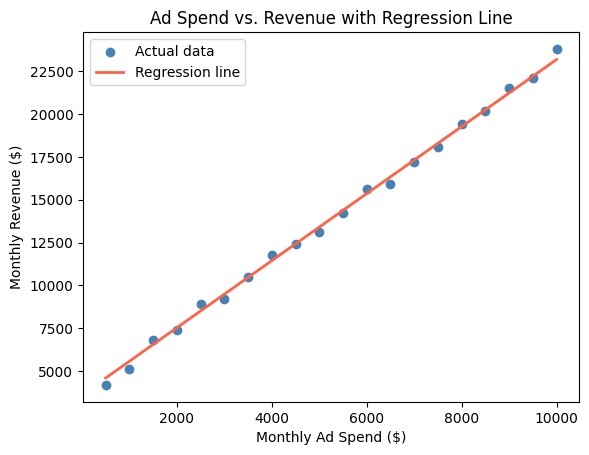

In [25]:
plt.scatter(
    X2,
    y2,
    color='steelblue',
    label='Actual data'
)

x2_range = np.linspace(
    X2['monthly_ad_spend'].min(),
    X2['monthly_ad_spend'].max(),
    100
).reshape(-1, 1)

y2_line = model2.predict(x2_range)

plt.plot(
    x2_range,
    y2_line,
    color='tomato',
    linewidth=2,
    label='Regression line'
)

plt.xlabel('Monthly Ad Spend ($)')
plt.ylabel('Monthly Revenue ($)')
plt.title('Ad Spend vs. Revenue with Regression Line')
plt.legend()

plt.show()

The regression line appears to fit the data well because the points follow an upward pattern and stay close to the line. This matches the R² score because a high R² means ad spend explains a large amount of the variation in revenue.